In [5]:
# Cell 5 — Line-support sensitivity

support_summary = (
    fixed_rr_df.groupby(
        ["representation", "target_rr"],
        observed=True,
    )
    .agg(
        n_windows=("window_id", "size"),
        median_diagonal_lines=("n_diagonal_lines", "median"),
        median_vertical_lines=("n_vertical_lines", "median"),
        fraction_zero_diagonal=(
            "n_diagonal_lines",
            lambda values: float((values == 0).mean()),
        ),
        fraction_zero_vertical=(
            "n_vertical_lines",
            lambda values: float((values == 0).mean()),
        ),
    )
    .reset_index()
)

overall_support = (
    fixed_rr_df.groupby("target_rr", observed=True)
    .agg(
        median_diagonal_lines=("n_diagonal_lines", "median"),
        median_vertical_lines=("n_vertical_lines", "median"),
        fraction_zero_diagonal=(
            "n_diagonal_lines",
            lambda values: float((values == 0).mean()),
        ),
        fraction_zero_vertical=(
            "n_vertical_lines",
            lambda values: float((values == 0).mean()),
        ),
    )
    .reset_index()
)

display(overall_support)
display(support_summary)


,target_rr,median_diagonal_lines,median_vertical_lines,fraction_zero_diagonal,fraction_zero_vertical
0,0.01,8608.0,22327.0,0.0,0.0
1,0.02,15988.0,50407.0,0.0,0.0
2,0.03,22952.0,79412.0,0.0,0.0
3,0.05,35970.0,128034.0,0.0,0.0


,representation,target_rr,n_windows,median_diagonal_lines,median_vertical_lines,fraction_zero_diagonal,fraction_zero_vertical
0,Processed,0.01,50,8419.5,23374.0,0.0,0.0
1,Processed,0.02,50,16047.0,53222.5,0.0,0.0
2,Processed,0.03,50,23220.0,81509.5,0.0,0.0
3,Processed,0.05,50,37081.0,132661.5,0.0,0.0
4,Raw,0.01,55,8745.0,20331.0,0.0,0.0
5,Raw,0.02,55,15844.0,34882.0,0.0,0.0
6,Raw,0.03,55,22146.0,45754.0,0.0,0.0
7,Raw,0.05,55,32747.0,63693.0,0.0,0.0


Awake/Drowsy curves are descriptive only.


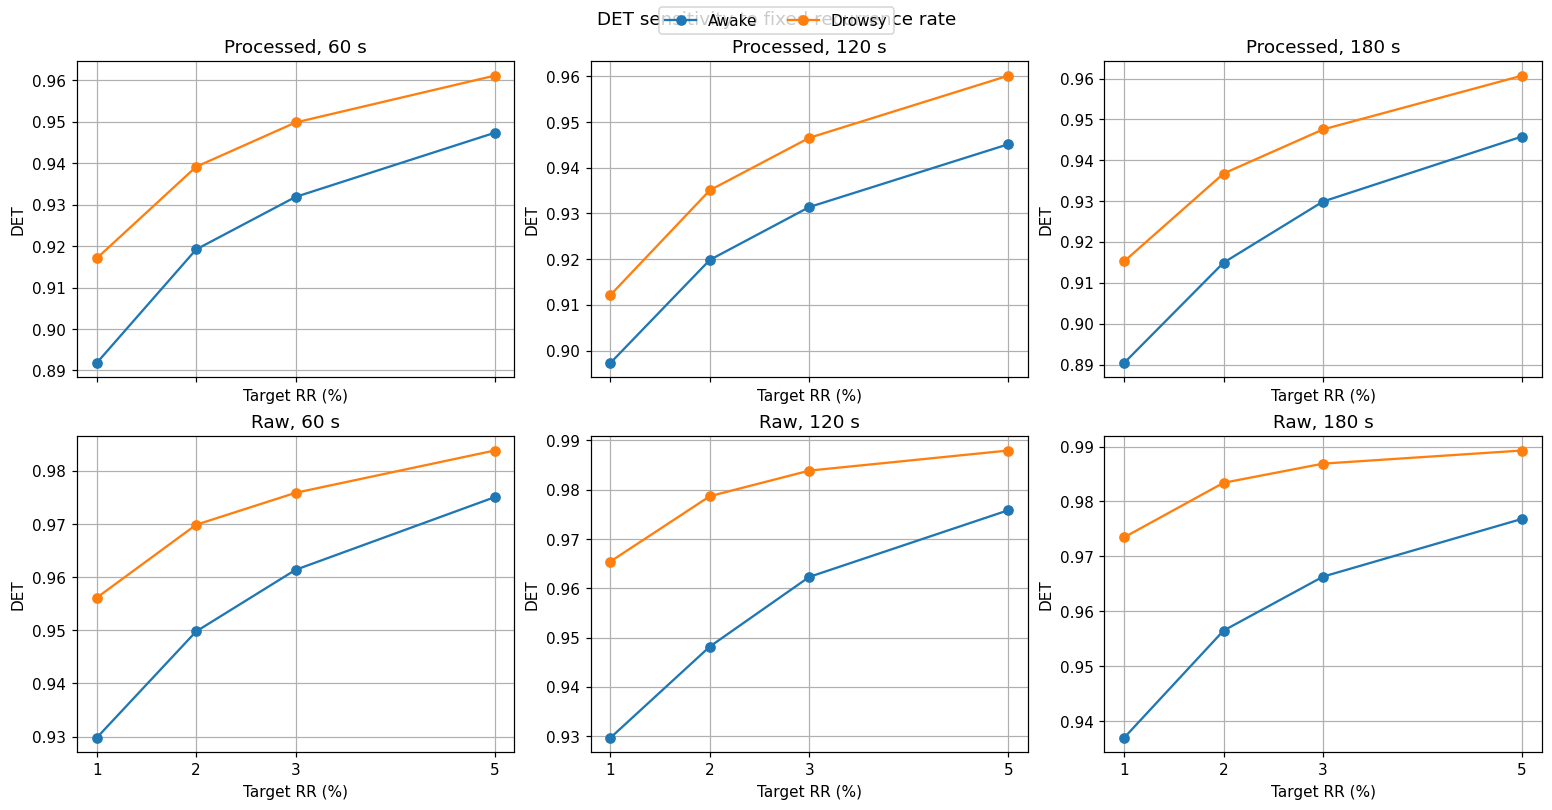

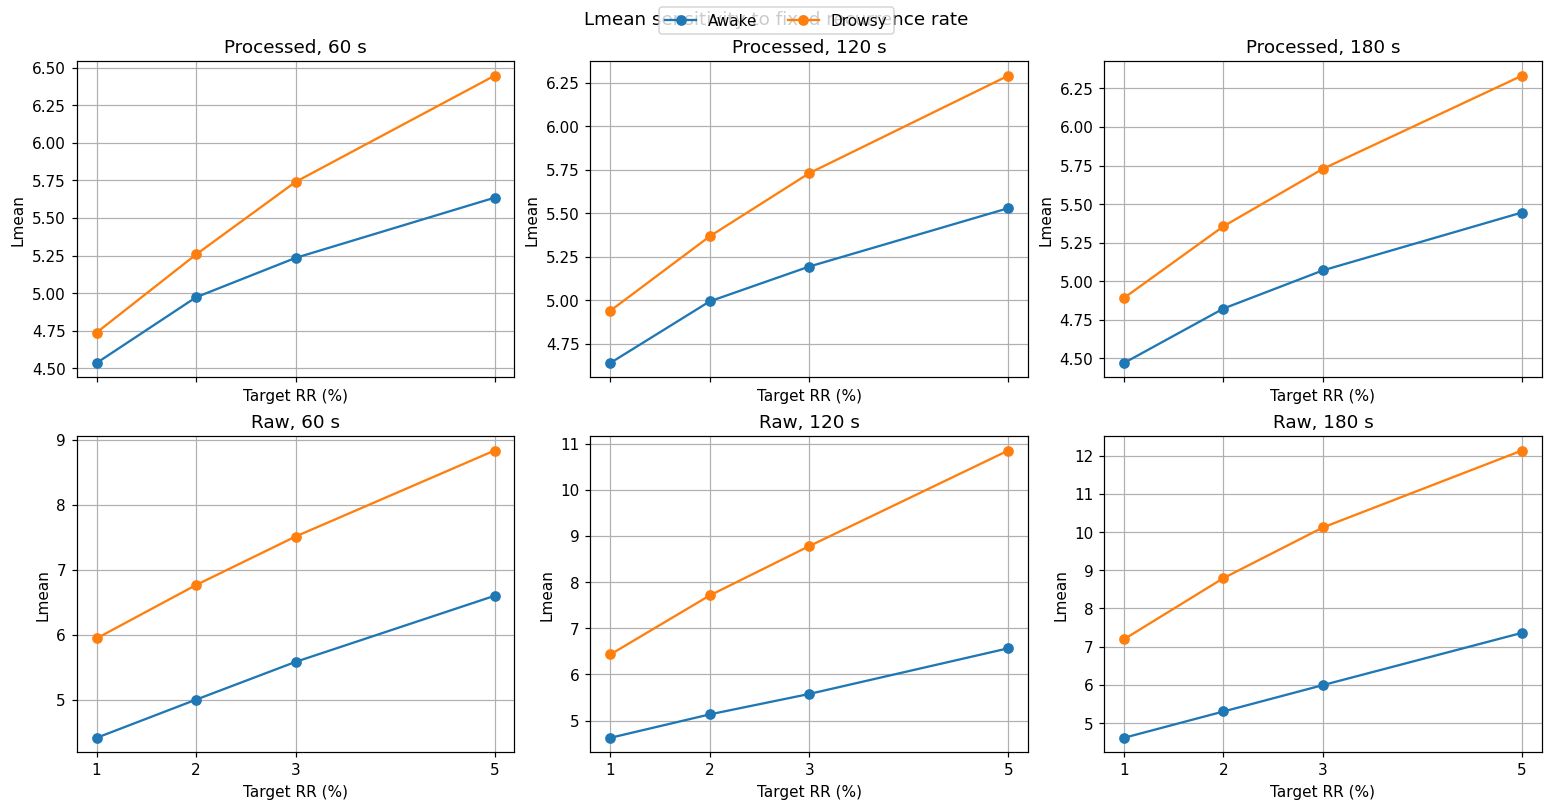

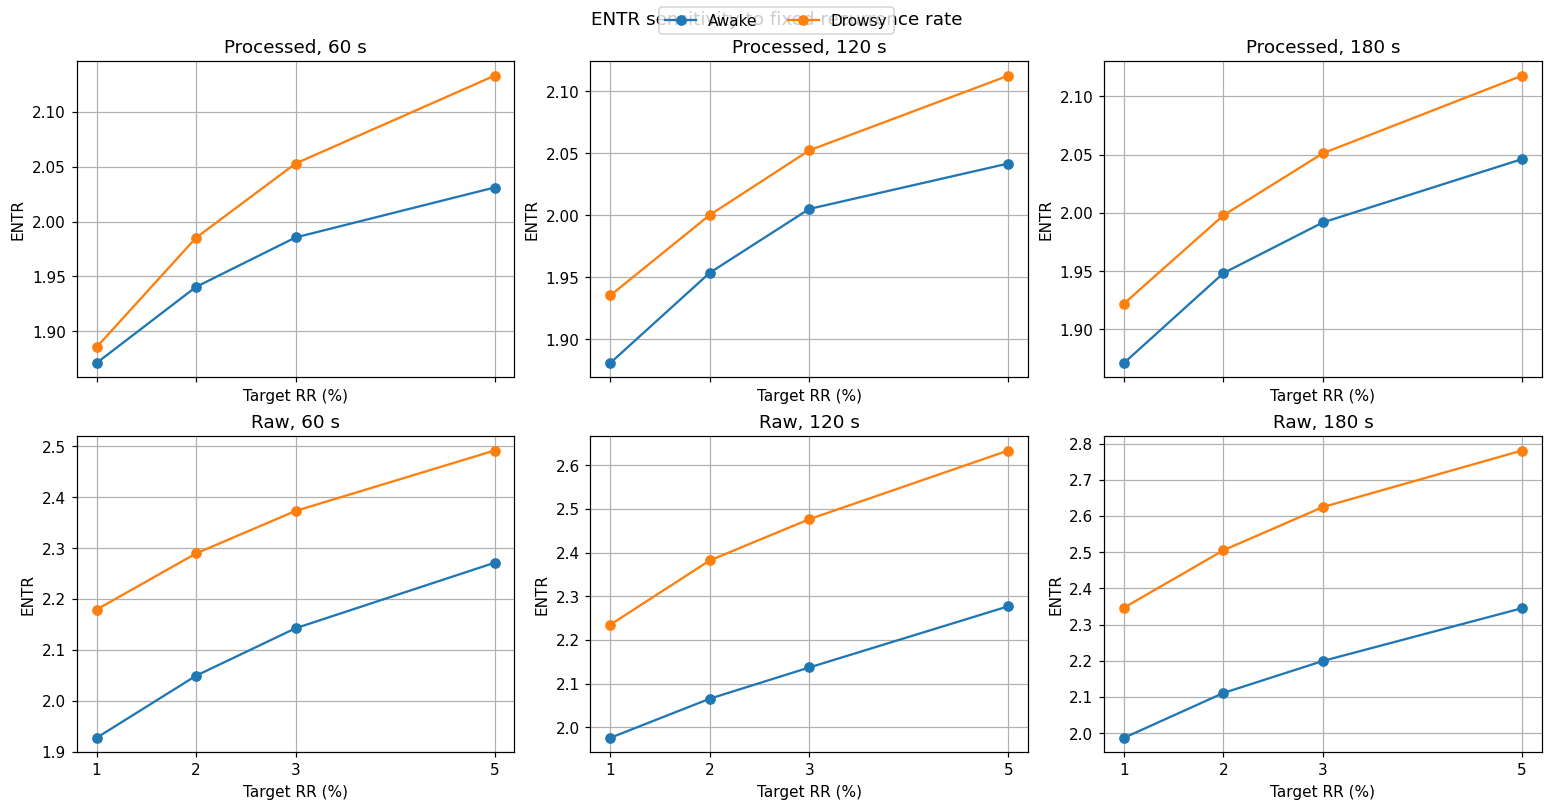

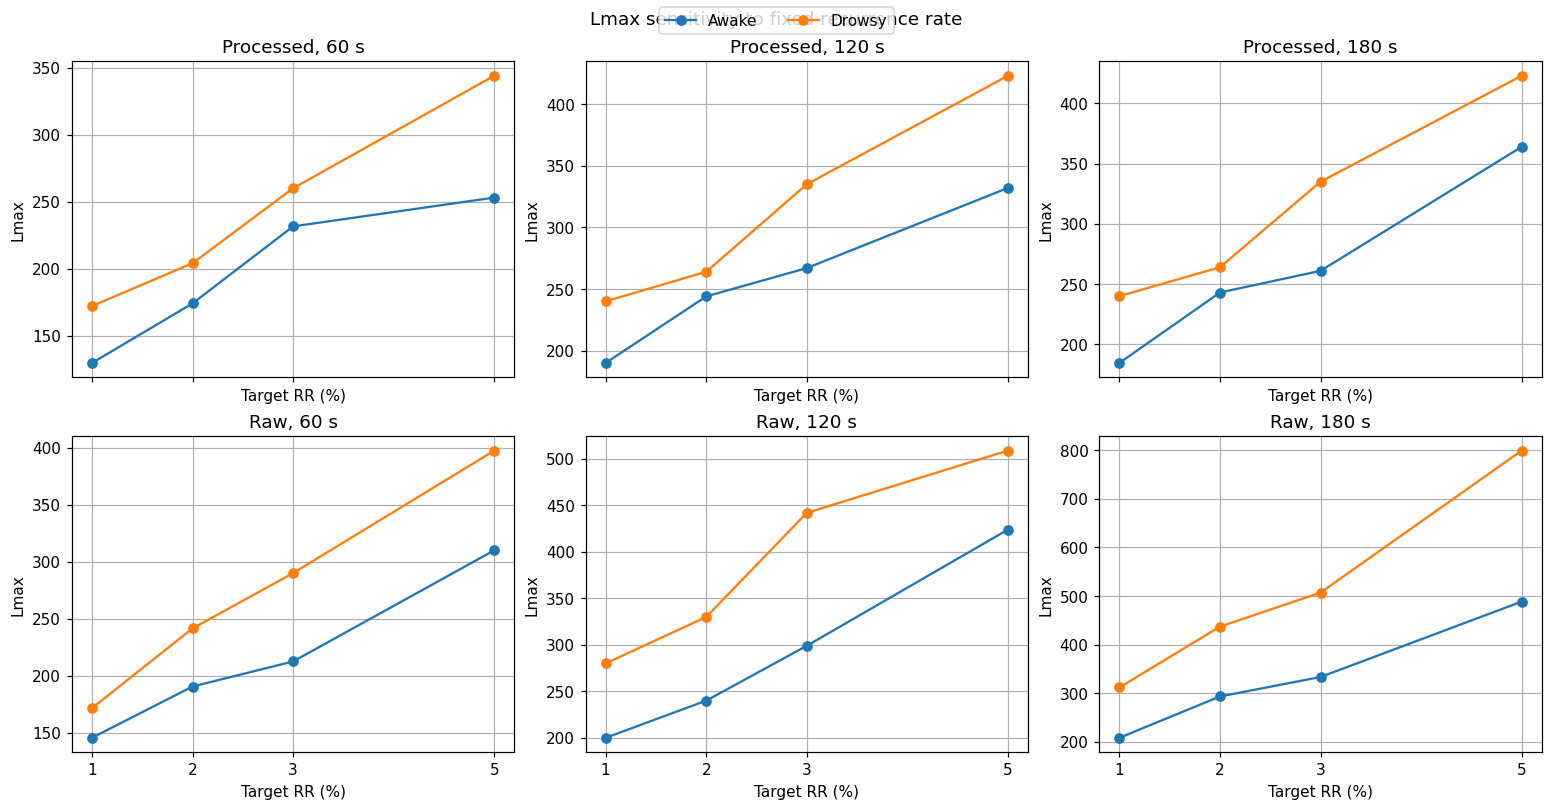

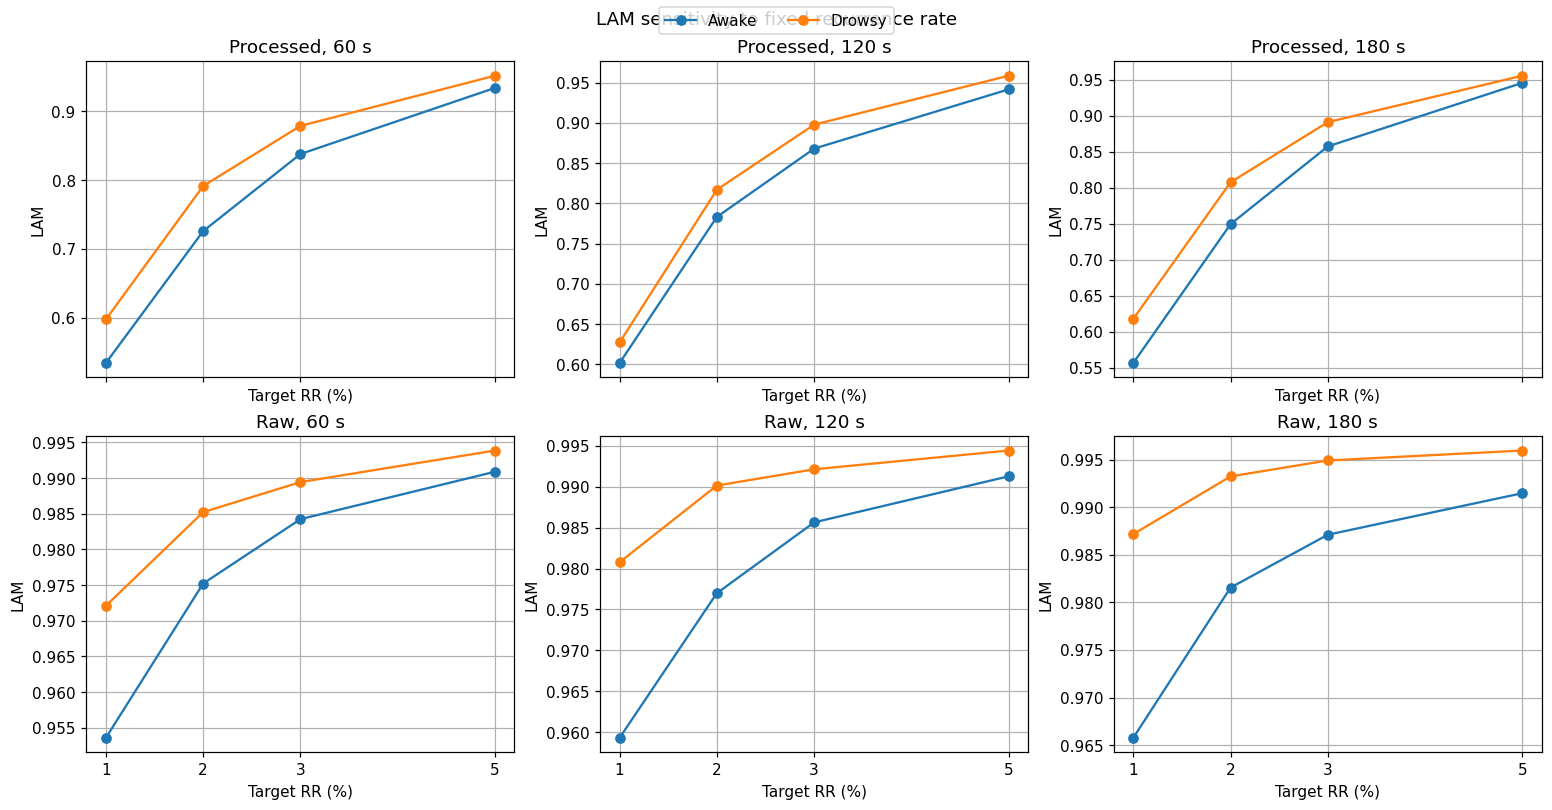

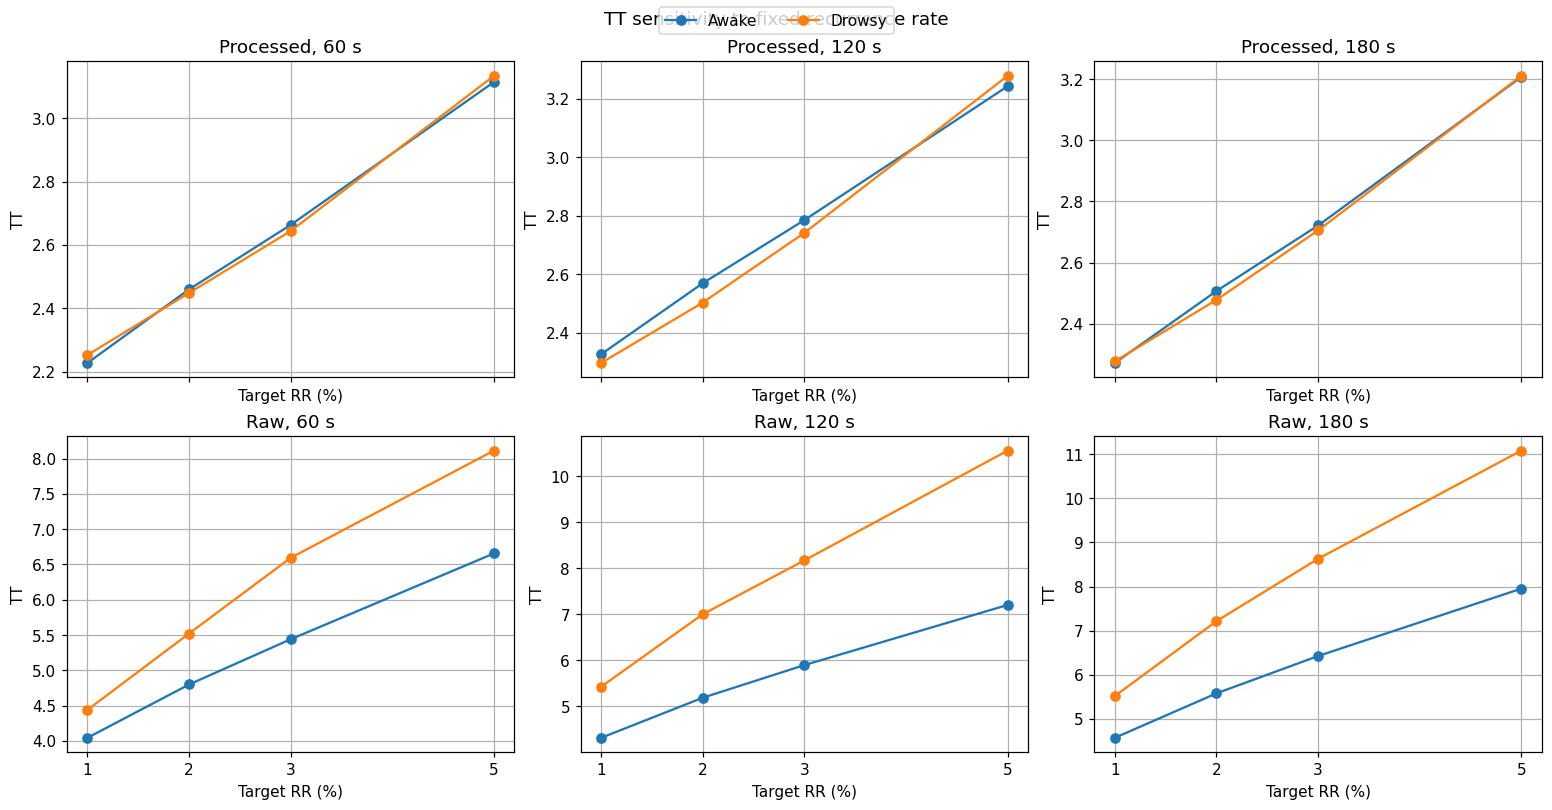

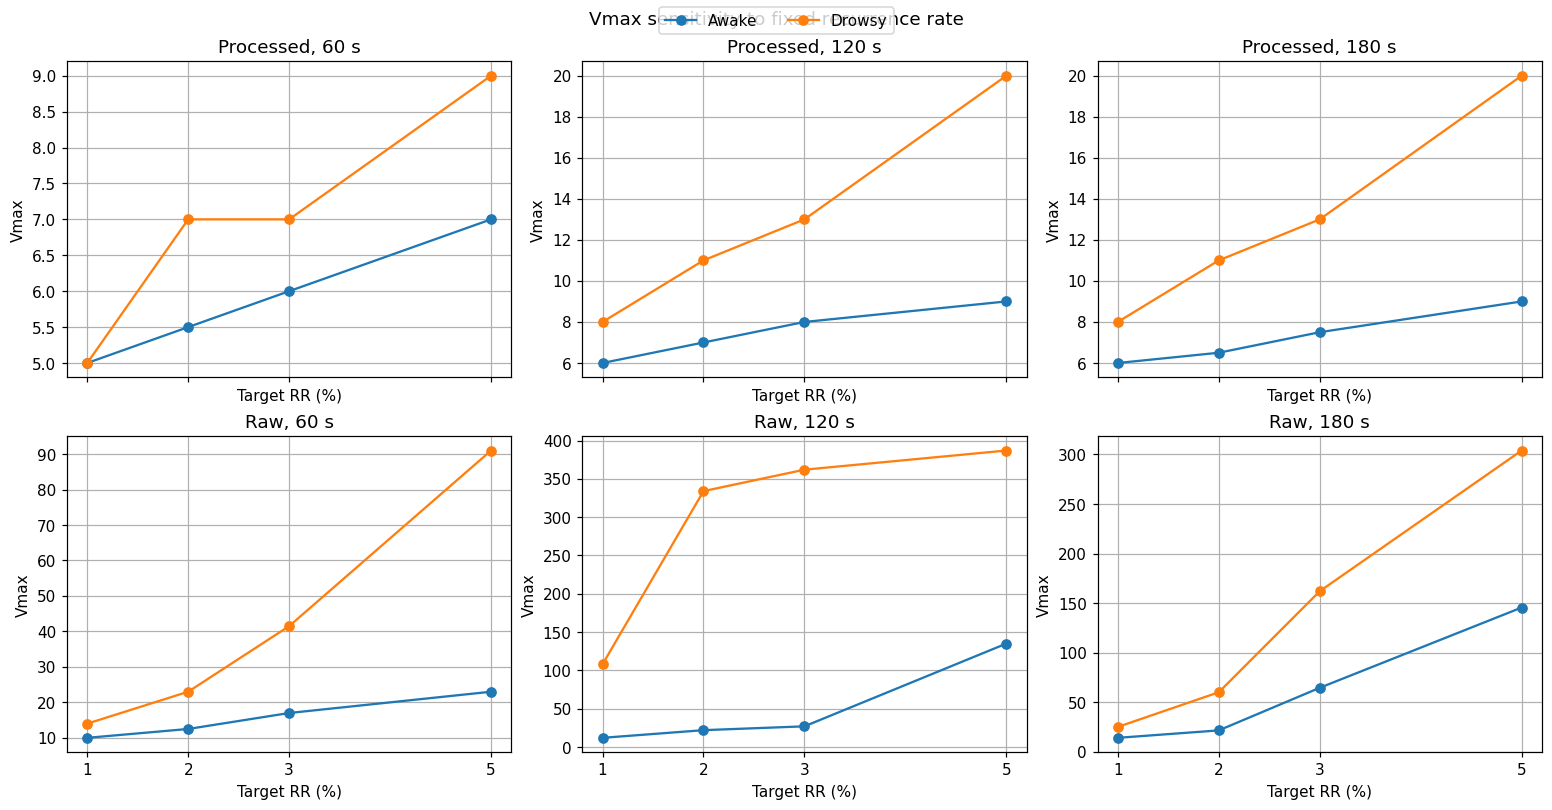

In [6]:
# Cell 6 — Metric sensitivity

METRICS = ("DET", "Lmean", "ENTR", "Lmax", "LAM", "TT", "Vmax")
metric_summary = (
    fixed_rr_df.groupby(
        [
            "representation",
            "state",
            "window_size",
            "target_rr",
        ],
        observed=True,
    )[list(METRICS)]
    .median()
    .reset_index()
)


def plot_fixed_rr_metric(metric):
    """Plot one metric across target recurrence rates."""
    representations = ("Processed", "Raw")
    colors = {"Awake": "tab:blue", "Drowsy": "tab:orange"}
    fig, axes = plt.subplots(
        len(representations),
        len(WINDOW_SIZES),
        figsize=(14, 7),
        sharex=True,
        constrained_layout=True,
    )

    for row, representation in enumerate(representations):
        for column, window_size in enumerate(WINDOW_SIZES):
            axis = axes[row, column]
            panel = metric_summary.loc[
                (metric_summary["representation"] == representation)
                & (metric_summary["window_size"] == window_size)
            ]
            for state in ("Awake", "Drowsy"):
                values = panel.loc[panel["state"] == state]
                if values.empty:
                    continue
                axis.plot(
                    100 * values["target_rr"],
                    values[metric],
                    marker="o",
                    color=colors[state],
                    label=state,
                )
            axis.set_title(f"{representation}, {window_size} s")
            axis.set_xlabel("Target RR (%)")
            axis.set_ylabel(metric)
            axis.set_xticks(100 * RR_TARGETS)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(f"{metric} sensitivity to fixed recurrence rate", y=1.03)
    plt.show()


print("Awake/Drowsy curves are descriptive only.")
for metric in METRICS:
    plot_fixed_rr_metric(metric)


In [7]:
# Cell 7 — Relative metric stability

window_keys = [
    "representation",
    "state",
    "window_size",
    "window_id",
]
relative_rows = []
for metric in METRICS:
    reference = (
        fixed_rr_df.loc[
            np.isclose(fixed_rr_df["target_rr"], RR_REFERENCE),
            window_keys + [metric],
        ]
        .rename(columns={metric: "reference"})
    )
    compared = fixed_rr_df[
        window_keys + ["target_rr", metric]
    ].merge(
        reference,
        on=window_keys,
        how="inner",
        validate="many_to_one",
    )
    compared["metric"] = metric
    compared["relative_change"] = (
        (compared[metric] - compared["reference"]).abs()
        / (compared["reference"].abs() + 1e-12)
    )
    relative_rows.append(
        compared[
            window_keys
            + ["target_rr", "metric", "relative_change"]
        ]
    )

relative_change_df = pd.concat(relative_rows, ignore_index=True)
relative_stability_table = (
    relative_change_df.groupby(
        ["metric", "target_rr"],
        observed=True,
    )["relative_change"]
    .median()
    .unstack("target_rr")
    .reindex(columns=RR_TARGETS)
)
relative_stability_table.columns = [
    f"{100 * target:.0f}%" for target in relative_stability_table.columns
]

display(relative_stability_table)
print("RR = 3% is the diagnostic reference; no RR is selected here.")


,1%,2%,3%,5%
metric,,,,
DET,0.033541,0.011817,0.0,0.014348
ENTR,0.075123,0.029988,0.0,0.044252
LAM,0.057245,0.015606,0.0,0.012024
Lmax,0.361217,0.157718,0.0,0.243446
Lmean,0.171067,0.076589,0.0,0.133937
TT,0.219937,0.103389,0.0,0.198222
Vmax,0.333333,0.166667,0.0,0.333333


RR = 3% is the diagnostic reference; no RR is selected here.


In [8]:
# Cell 8 — Final decision table

metric_stability = (
    relative_change_df.groupby("target_rr", observed=True)
    ["relative_change"]
    .median()
    .rename("Metric stability")
)

representation_validity = (
    representation_density_qc.assign(
        valid=lambda data: (
            data["maximum_absolute_error"] <= RR_TOLERANCE
        )
    )
    .groupby("target_rr", observed=True)["valid"]
    .all()
    .rename("Raw/Processed valid")
)

zero_support = (
    fixed_rr_df.assign(
        zero_support=(
            (fixed_rr_df["n_diagonal_lines"] == 0)
            | (fixed_rr_df["n_vertical_lines"] == 0)
        )
    )
    .groupby("target_rr", observed=True)["zero_support"]
    .mean()
    .rename("Zero support")
)

decision_table = (
    overall_support.set_index("target_rr")
    .rename(
        columns={
            "median_diagonal_lines": "Diagonal support",
            "median_vertical_lines": "Vertical support",
        }
    )
    [["Diagonal support", "Vertical support"]]
    .join(zero_support)
    .join(metric_stability)
    .join(representation_validity)
    .reset_index()
    .rename(columns={"target_rr": "RR"})
)

display(decision_table)
print("Freeze criterion:")
print("Choose the lowest RR with adequate line support and stable metrics.")
print("Prefer local recurrence without sacrificing statistical support.")
print("Decision: TO REVIEW")


,RR,Diagonal support,Vertical support,Zero support,Metric stability,Raw/Processed valid
0,0.01,8608.0,22327.0,0.0,0.166667,True
1,0.02,15988.0,50407.0,0.0,0.067953,True
2,0.03,22952.0,79412.0,0.0,0.000000,True
3,0.05,35970.0,128034.0,0.0,0.102102,True


Freeze criterion:
Choose the lowest RR with adequate line support and stable metrics.
Prefer local recurrence without sacrificing statistical support.
Decision: TO REVIEW


# Tổng hợp kết quả fixed-RR pilot trên Session 1

## 1. Cấu hình và dữ liệu

- Embedding dimension: `m = 8`.
- Delay: Processed `tau = 0.16 s`; Raw `tau = 0.20 s`.
- Theiler window: `W = (m - 1) * tau`.
- Line cutoffs: `l_min = 2`, `v_min = 2`.
- Distance: Euclidean.
- Target recurrence rates: `1%`, `2%`, `3%`, `5%`.
- Processed dùng các window qua Processed stationarity.
- Raw dùng toàn bộ window qua SQI, không lọc stationarity.
- Tổng số window: `105`, gồm `50` Processed và `55` Raw.
- Mỗi window chỉ tính embedding và pairwise distances một lần; cùng distance
  vector được dùng lại cho cả bốn target RR.

## 2. Kiểm tra implementation fixed-RR

Kết quả trên representative Processed–Awake window 120 giây:

| Target RR | Epsilon | Achieved RR | Absolute error |
|---:|---:|---:|---:|
| 1% | 93.298415 | 0.010000 | 4.15e-08 |
| 2% | 116.838662 | 0.020000 | 2.54e-08 |
| 3% | 136.217605 | 0.030000 | 9.23e-09 |
| 5% | 171.719669 | 0.050000 | 3.46e-08 |

Implementation check đạt `PASS`. Epsilon được xác định từ quantile của các
upper-triangle distances nằm ngoài Theiler corridor; epsilon không còn được
tính bằng `0.1 * Dmax`.

## 3. Recurrence-density QC trên toàn Session 1

| Target RR | Median achieved RR | Min achieved RR | Max achieved RR | Maximum absolute error | Zero diagonal support | Zero vertical support |
|---:|---:|---:|---:|---:|---:|---:|
| 1% | 0.010000 | 0.010000 | 0.010001 | 8.07e-07 | 0 | 0 |
| 2% | 0.020000 | 0.020000 | 0.020001 | 1.37e-06 | 0 | 0 |
| 3% | 0.030000 | 0.030000 | 0.030001 | 9.54e-07 | 0 | 0 |
| 5% | 0.050000 | 0.050000 | 0.050001 | 1.35e-06 | 0 | 0 |

Raw và Processed đều đạt target recurrence density với sai số nhỏ hơn nhiều
so với tolerance `5e-4`. Recurrence-density QC đạt `PASS`. Trường hợp Raw có
RR khoảng `0.51` dưới rule `0.1 * Dmax` không còn xuất hiện trong fixed-RR.

## 4. Line support

| Target RR | Median diagonal lines | Median vertical lines | Fraction zero diagonal | Fraction zero vertical |
|---:|---:|---:|---:|---:|
| 1% | 8,608 | 22,327 | 0.000 | 0.000 |
| 2% | 15,988 | 50,407 | 0.000 | 0.000 |
| 3% | 22,952 | 79,412 | 0.000 | 0.000 |
| 5% | 35,970 | 128,034 | 0.000 | 0.000 |

Không có window mất diagonal hoặc vertical support, kể cả tại RR `1%`.
Số qualifying lines tăng theo target RR ở cả Raw và Processed. Trong grid đã
kiểm tra, RR thấp chưa tạo ra RP sparse đến mức mất line support.

## 5. Relative metric stability

RR `3%` được dùng làm reference diagnostic. Các giá trị dưới đây là median
relative change qua windows:

| Metric | 1% | 2% | 3% | 5% |
|---|---:|---:|---:|---:|
| DET | 0.033541 | 0.011817 | 0.000000 | 0.014348 |
| ENTR | 0.075123 | 0.029988 | 0.000000 | 0.044252 |
| LAM | 0.057245 | 0.015606 | 0.000000 | 0.012024 |
| Lmax | 0.361217 | 0.157718 | 0.000000 | 0.243446 |
| Lmean | 0.171067 | 0.076589 | 0.000000 | 0.133937 |
| TT | 0.219937 | 0.103389 | 0.000000 | 0.198222 |
| Vmax | 0.333333 | 0.166667 | 0.000000 | 0.333333 |

DET, ENTR và LAM thay đổi ít hơn các metric phụ thuộc line length. Lmax,
Lmean, TT và Vmax có relative change lớn hơn khi target RR dịch xa reference
`3%`. Curves Awake/Drowsy chỉ được hiển thị mô tả và không được dùng để chọn
RR.

## 6. Final decision table

| RR | Diagonal support | Vertical support | Zero support | Metric stability | Raw/Processed valid |
|---:|---:|---:|---:|---:|---|
| 1% | 8,608 | 22,327 | 0.000 | 0.166667 | True |
| 2% | 15,988 | 50,407 | 0.000 | 0.067953 | True |
| 3% | 22,952 | 79,412 | 0.000 | 0.000000 | True |
| 5% | 35,970 | 128,034 | 0.000 | 0.102102 | True |

Fixed-RR đã đồng nhất recurrence density giữa Raw và Processed, đồng thời giữ
đủ diagonal và vertical support trên toàn bộ grid. `1%` có line support nhưng
metric change lớn hơn; `2%` có metric change nhỏ hơn `1%` và `5%` khi so với
reference `3%`. Kết quả này là evidence cho bước review, không phải lựa chọn
tự động.

**Decision: TO REVIEW.**